In [1]:
import os
import torch
from timm import create_model
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from collections import defaultdict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import json

In this task, we focus on evaluating the representational quality of different layers in a pretrained Vision Transformer model, specifically the DINO self-supervised model. We extract features from each transformer block and train lightweight linear classifiers (linear probes). This procedure allows us to measure how linearly separable the learned features are at each depth of the network. The primary goal is to understand which layers encode the most useful semantic information for classification tasks. This analysis serves as a foundation for subsequent investigations, such as layer-skipping strategies or representational redundancy detection, aiming to optimize inference without significantly sacrificing model performance.

In [ ]:
import os
import random
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

base_train_dir = "..\\data"
train_dirs = [os.path.join(base_train_dir, f"train.X{i}") for i in range(1, 5)]
val_path = os.path.join(base_train_dir, "val.X")

train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_datasets = [datasets.ImageFolder(train_dir, transform=train_transform) for train_dir in train_dirs]

# selected_classes = []
# for ds in train_datasets:
#     all_classes = ds.classes
#     random_classes = random.sample(all_classes, 2)
#     selected_classes.extend(random_classes)


selected_classes = ['n01632777', 'n01984695', 'n01728572', 'n01514859',
                    'n01614925', 'n01582220', 'n01806143', 'n01819313']


print("Selected classes:", selected_classes)

all_class_to_idx = {}
for ds in train_datasets:
    all_class_to_idx.update(ds.class_to_idx)
class_indices = [all_class_to_idx[cls] for cls in selected_classes]

def get_class_subset(dataset, class_indices):
    selected = [i for i, (_, label) in enumerate(dataset.samples) if label in class_indices]
    return Subset(dataset, selected)

train_subsets = [get_class_subset(ds, [ds.class_to_idx[cls] for cls in ds.classes if cls in selected_classes]) for ds in train_datasets]
train_subset = ConcatDataset(train_subsets)

val_dataset = datasets.ImageFolder(val_path, transform=val_transform)
val_subset = get_class_subset(val_dataset, class_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

def get_labels_from_loader(loader):
    labels = []
    for _, batch_labels in loader:
        labels.extend(batch_labels.numpy())
    return np.array(labels)

y_train = get_labels_from_loader(train_loader)
y_val = get_labels_from_loader(val_loader)

unique_labels = np.unique(y_train)
label_mapping = {old_label: new_idx for new_idx, old_label in enumerate(unique_labels)}

y_train = np.array([label_mapping[lbl] for lbl in y_train])
y_val = np.array([label_mapping[lbl] for lbl in y_val])

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}


Selected classes: ['n01632777', 'n01984695', 'n01728572', 'n01514859', 'n01614925', 'n01582220', 'n01806143', 'n01819313']


In [16]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Using cache found in C:\Users\okroj/.cache\torch\hub\facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [17]:
@torch.no_grad()
def collect_model_outputs(model, dataloader, max_batches=None):
    outputs = []
    for i, (images, _) in enumerate(dataloader):
        if max_batches and i >= max_batches:
            break
        images = images.to(device)
        out = model(images) 
        outputs.append(out.detach().cpu())
    return torch.cat(outputs, dim=0)

In [ ]:
print("Collecting train outputs...")
train_outputs = collect_model_outputs(model, train_loader)

print("Collecting val outputs...")
val_outputs = collect_model_outputs(model, val_loader)

Batch 1 done in 9.54s
Batch 2 done in 9.22s
Batch 3 done in 9.55s
Batch 4 done in 9.26s
Batch 5 done in 9.67s
Batch 6 done in 8.94s
Batch 7 done in 8.99s
Batch 8 done in 9.37s
Batch 9 done in 10.16s
Batch 10 done in 9.64s
Batch 11 done in 9.89s
Batch 12 done in 9.93s
Batch 13 done in 9.24s
Batch 14 done in 9.87s
Batch 15 done in 9.21s
Batch 16 done in 8.85s
Batch 17 done in 8.87s
Batch 18 done in 9.02s
Batch 19 done in 8.91s
Batch 20 done in 9.01s
Batch 21 done in 8.82s
Batch 22 done in 9.02s
Batch 23 done in 8.88s
Batch 24 done in 9.01s
Batch 25 done in 8.82s
Batch 26 done in 8.94s
Batch 27 done in 8.99s
Batch 28 done in 8.98s
Batch 29 done in 8.72s
Batch 30 done in 8.77s
Batch 31 done in 8.70s
Batch 32 done in 9.11s
Batch 33 done in 8.88s
Batch 34 done in 8.91s
Batch 35 done in 8.91s
Batch 36 done in 8.85s
Batch 37 done in 8.85s
Batch 38 done in 8.92s
Batch 39 done in 9.06s
Batch 40 done in 8.88s
Batch 41 done in 8.90s
Batch 42 done in 8.83s
Batch 43 done in 8.94s
Batch 44 done in 8.

In [21]:
X_train = train_outputs.numpy()
X_val = val_outputs.numpy()

print("Training classifier on model output...")

clf = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    class_weight=class_weight_dict
)
clf.fit(X_train, y_train)

y_val_pred = clf.predict(X_val)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, average='macro', zero_division=0)
rec = recall_score(y_val, y_val_pred, average='macro', zero_division=0)
f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

print(f"\n→ Val Accuracy: {acc:.4f}")
print(f"→ Val Precision: {prec:.4f}")
print(f"→ Val Recall: {rec:.4f}")
print(f"→ Val F1-score: {f1:.4f}")

os.makedirs("linear_probes", exist_ok=True)
joblib.dump(clf, "../linear_probe/final_linear_probe_2.joblib")

metrics_dict = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

with open("metrics_dict.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

Training classifier on model output...

→ Val Accuracy: 0.5200
→ Val Precision: 0.5200
→ Val Recall: 0.5200
→ Val F1-score: 0.5198


## Layer Skipping

In [ ]:
from tqdm import tqdm

model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

clf = joblib.load("../linear_probe/final_linear_probe_2.joblib")

@torch.no_grad()
def forward_with_skipping(model, x, skip_layers=[]):
    x = model.patch_embed(x)
    cls_token = model.cls_token.expand(x.shape[0], -1, -1)
    x = torch.cat((cls_token, x), dim=1)
    x = x + model.pos_embed
    x = model.pos_drop(x)

    for i, blk in enumerate(model.blocks):
        if i in skip_layers:
            continue
        x = blk(x)

    x = model.norm(x)
    cls_token_out = x[:, 0]
    return cls_token_out

@torch.no_grad()
def collect_outputs_with_skipping(model, dataloader, skip_layers=[], max_batches=None):
    outputs = []
    all_labels = []
    for i, (images, labels) in enumerate(tqdm(dataloader, desc="Collecting outputs")):
        if max_batches and i >= max_batches:
            break
        images = images.to(device)
        cls_token_out = forward_with_skipping(model, images, skip_layers)
        outputs.append(cls_token_out.cpu())
        all_labels.extend(labels.numpy())

    return torch.cat(outputs).numpy(), np.array(all_labels)

Using cache found in C:\Users\okroj/.cache\torch\hub\facebookresearch_dino_main


In [ ]:
def evaluate_skipped_layers(model, dataloader, classifier, max_layer=12, max_batches=None):

    """
    Evaluates the impact of skipping individual and consecutive pairs of layers 
    in a transformer model on classification performance.

    For each layer and each pair of consecutive layers up to `max_layer`, the function:
    - Skips the specified layers during the forward pass.
    - Extracts intermediate representations.
    - Evaluates a fixed classifier on the resulting features.
    - Computes accuracy, precision, recall, and F1 score.
    """
    results = []

    print("\n[INFO] Evaluating individual skipped layers...\n")
    for i in range(max_layer):
        skipped = [i]
        print(f"\n[INFO] Skipping layer: {skipped}")
        X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=skipped, max_batches=max_batches)
        y_pred = classifier.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

        print(f"→ Accuracy: {acc:.4f}")

        results.append({
            'skipped_layers': skipped,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1
        })

    print("\n[INFO] Evaluating pairs of consecutive skipped layers...\n")
    for i in range(max_layer - 1):
        skipped = [i, i + 1]
        print(f"\n[INFO] Skipping layers: {skipped}")
        X_val, y_val = collect_outputs_with_skipping(model, dataloader, skip_layers=skipped, max_batches=max_batches)
        y_pred = classifier.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)

        results.append({
            'skipped_layers': skipped,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1
        })

    return results

In [39]:
results = evaluate_skipped_layers(model, val_loader, clf)


[INFO] Evaluating individual skipped layers...


[INFO] Skipping layer: [0]


torch.Size([64, 384])


torch.Size([36, 384])
→ Accuracy: 0.5000

[INFO] Skipping layer: [1]


torch.Size([64, 384])


torch.Size([36, 384])
→ Accuracy: 0.4800

[INFO] Skipping layer: [2]


...

torch.Size([36, 384])

[INFO] Skipping layers: [9, 10]


torch.Size([64, 384])


torch.Size([36, 384])

[INFO] Skipping layers: [10, 11]


torch.Size([64, 384])


torch.Size([36, 384])


In [ ]:
results

[{'skipped_layers': [0],
  'accuracy': 0.5,
  'precision': 0.25,
  'recall': 0.5,
  'f1_score': 0.3333333333333333},
 {'skipped_layers': [1],
  'accuracy': 0.48,
  'precision': 0.47970779220779225,
  'recall': 0.48,
  'f1_score': 0.4781212364512244},
 {'skipped_layers': [2],
  'accuracy': 0.52,
  'precision': 0.5212224108658743,
  'recall': 0.52,
  'f1_score': 0.512987012987013},
 {'skipped_layers': [3],
  'accuracy': 0.54,
  'precision': 0.5400641025641025,
  'recall': 0.54,
  'f1_score': 0.5398159263705482},
 {'skipped_layers': [4],
  'accuracy': 0.45,
  'precision': 0.449000407996736,
  'recall': 0.45,
  'f1_score': 0.4472917294744247},
 {'skipped_layers': [5],
  'accuracy': 0.55,
  'precision': 0.5505050505050505,
  'recall': 0.55,
  'f1_score': 0.5488721804511277},
 {'skipped_layers': [6],
  'accuracy': 0.53,
  'precision': 0.5310045473336089,
  'recall': 0.53,
  'f1_score': 0.5261619114830125},
 {'skipped_layers': [7],
  'accuracy': 0.46,
  'precision': 0.45993589743589747,
  're

In [42]:
def extract_layer_outputs(model, x):
    '''
    Extracts intermediate layer outputs from a ViT model during a forward pass.
    '''
    activations = []

    def hook_fn(module, input, output):
        activations.append(output)

    hooks = [blk.register_forward_hook(hook_fn) for blk in model.blocks]

    with torch.no_grad():
        _ = model(x)

    for hook in hooks:
        hook.remove()

    return activations


def compute_logits_from_layers(model, layer_outputs):
    '''
    Computes classification logits from intermediate layer representations using the model's head.
    '''
    cls_tokens = [output[:, 0] for output in layer_outputs]  # CLS token
    norm = model.norm
    head = model.head
    logits = [head(norm(cls)) for cls in cls_tokens]
    return logits


def collect_logits_from_batches(model, dataloader, max_batches=None):
    '''
    Collects logits from all transformer layers for multiple batches of data.
    '''
    all_logits = []

    for batch_idx, (x_batch, _) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_batch = x_batch.to(next(model.parameters()).device)
        layer_outputs = extract_layer_outputs(model, x_batch)
        logits = compute_logits_from_layers(model, layer_outputs)
        all_logits.append(logits)

    return all_logits

In [66]:
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)
from metrics.CKA import linear_CKA
from metrics.CKNNA import AlignmentMetrics

def compute_cka_matrix(logits):
    L = len(logits)
    matrix = torch.zeros(L, L)
    logits = [F.normalize(logit.detach(), dim=-1) for logit in logits]

    for i in range(L):
        for j in range(i, L):
            val = linear_CKA(logits[i], logits[j])
            matrix[i, j] = val
            matrix[j, i] = val

    return matrix.numpy()

def compute_cosine_similarity_matrix(logits):
    """
    Fully vectorized computation of cosine similarity matrix between L layer outputs.
    Uses F.cosine_similarity and removes nested loops.
    """
    x = torch.stack([F.normalize(t.detach(), dim=-1) for t in logits])

    x1 = x[:, None, :, :] 
    x2 = x[None, :, :, :]

    cos = F.cosine_similarity(x1, x2, dim=-1)

    sim_matrix = cos.mean(dim=-1)

    return sim_matrix.cpu().numpy()

def compute_cknna_matrix(logits, k=10):
    L = len(logits)
    matrix = np.zeros((L, L))
    
    for i in range(L):
        for j in range(i, L):
            sim = AlignmentMetrics.cknna(logits[i], logits[j], topk=k)
            matrix[i, j] = sim
            matrix[j, i] = sim
    
    return matrix

Please install the pymp library using `pip install pymp` to speed up non-batched metrics


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm


model.eval()

all_logits = collect_logits_from_batches(model, dataloader=train_loader, max_batches=20)

num_layers = len(all_logits[0])
combined_logits = []

for layer_idx in range(num_layers):
    layer_logits = [batch[layer_idx] for batch in all_logits]
    combined = torch.cat(layer_logits, dim=0)
    combined_logits.append(combined)

cka_matrix = compute_cka_matrix(combined_logits)
cos_matrix = compute_cosine_similarity_matrix(combined_logits)
cknna_matrix = compute_cknna_matrix(combined_logits)


In [ ]:
def plot_skip_layer_accuracy(results, similarity_matrix, title):
    """
    Plots accuracy vs skipping a single layer, coloring bars by CKA similarity between this layers.
    """
    single_skip_results = [res for res in results if len(res['skipped_layers']) == 1]

    cka_similarities = [
        similarity_matrix[i, i+1] if i < len(similarity_matrix) - 1 else similarity_matrix[i-1, i]
        for i in range(len(similarity_matrix))
    ]

    norm = plt.Normalize(min(cka_similarities), max(cka_similarities))
    colors = cm.viridis(norm(cka_similarities))

    x = [res['skipped_layers'][0] for res in single_skip_results]
    y = [res['accuracy'] for res in single_skip_results]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(x, y, color=colors)
    plt.axhline(y=0.52, color='r', linestyle='--', label='Full model accuracy (0.52)')
    plt.xlabel("Skipped layer")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\okroj\AppData\Local\Temp\ipykernel_11756\4017572041.py:25: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')


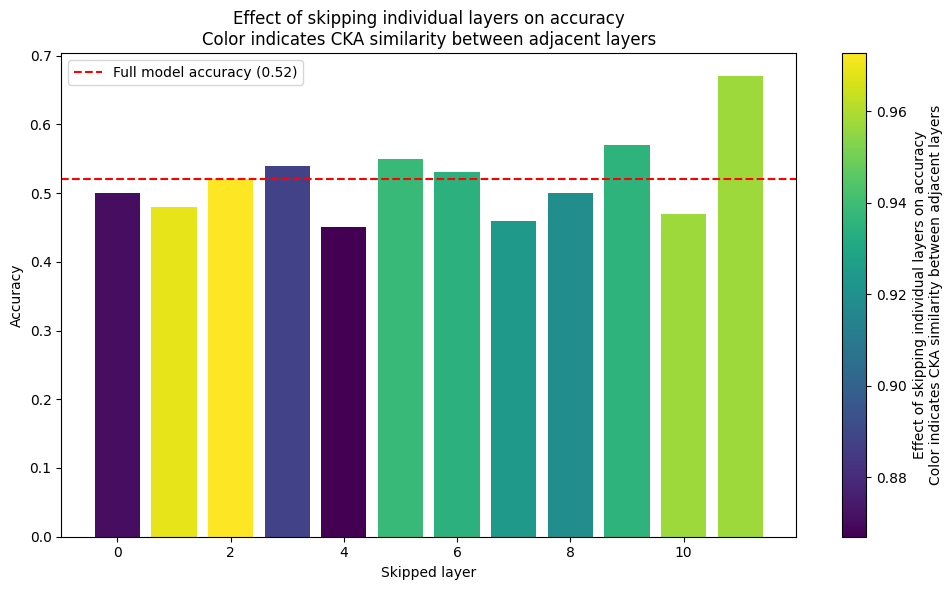

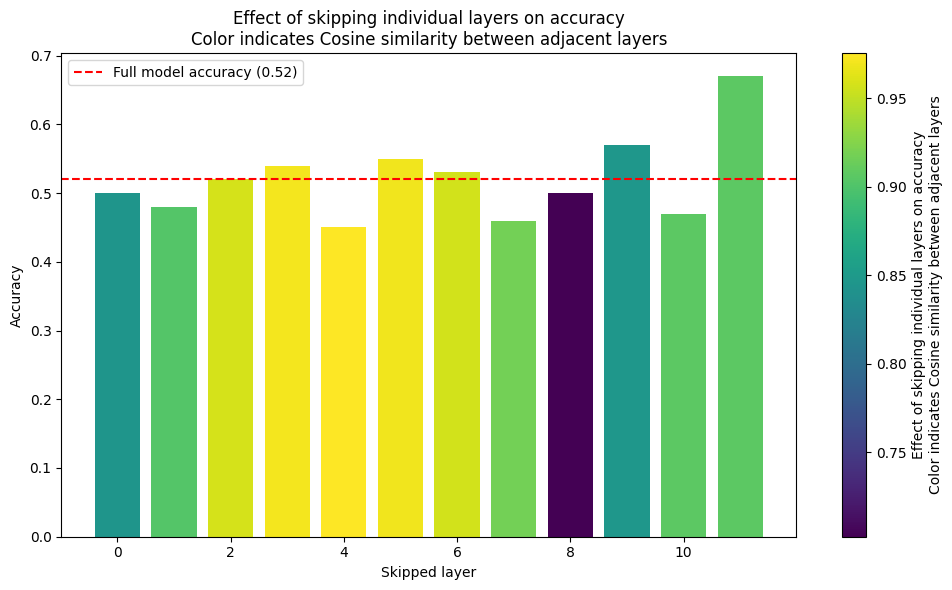

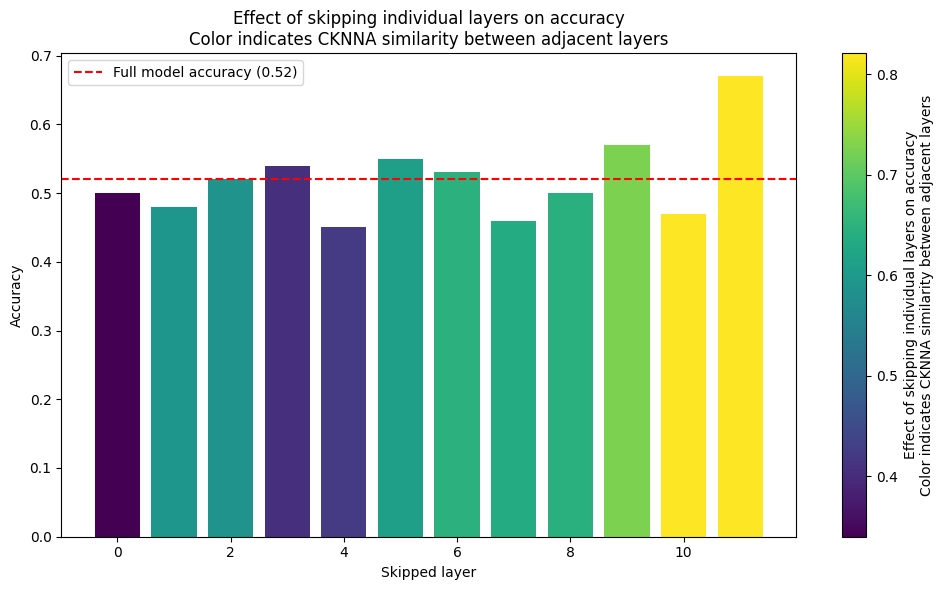

In [85]:
plot_skip_layer_accuracy(
    results,
    cka_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates CKA similarity between adjacent layers"
)

plot_skip_layer_accuracy(
    results,
    cos_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates Cosine similarity between adjacent layers"
)

plot_skip_layer_accuracy(
    results,
    cknna_matrix,
    "Effect of skipping individual layers on accuracy\nColor indicates CKNNA similarity between adjacent layers"
)


In [ ]:
def plot_double_skip_accuracy(results, similarity_matrix, title):
    """
    Plots accuracy vs skipping two consecutive layers, coloring bars by CKA similarity between those layers.
    """
    double_skip_results = [
        res for res in results
        if len(res['skipped_layers']) == 2 and res['skipped_layers'][1] - res['skipped_layers'][0] == 1
    ]

    cka_similarities = []
    for res in double_skip_results:
        i = res['skipped_layers'][0]
        if i + 2 < similarity_matrix.shape[0]:
            cka_similarities.append(similarity_matrix[i, i+2])
        else:
            cka_similarities.append(similarity_matrix[i-1, i])


    norm = plt.Normalize(min(cka_similarities), max(cka_similarities))
    colors = cm.viridis(norm(cka_similarities))

    x_labels = [f"{i}-{j}" for i, j in [res['skipped_layers'] for res in double_skip_results]]
    x_pos = np.arange(len(x_labels))
    accuracies = [res['accuracy'] for res in double_skip_results]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(x_pos, accuracies, color=colors)
    plt.axhline(y=0.52, color='r', linestyle='--', label='Full model accuracy (0.52)')
    plt.xticks(x_pos, x_labels)
    plt.xlabel("Skipped layers")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\okroj\AppData\Local\Temp\ipykernel_11756\4015912689.py:37: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), label=f'{title}')


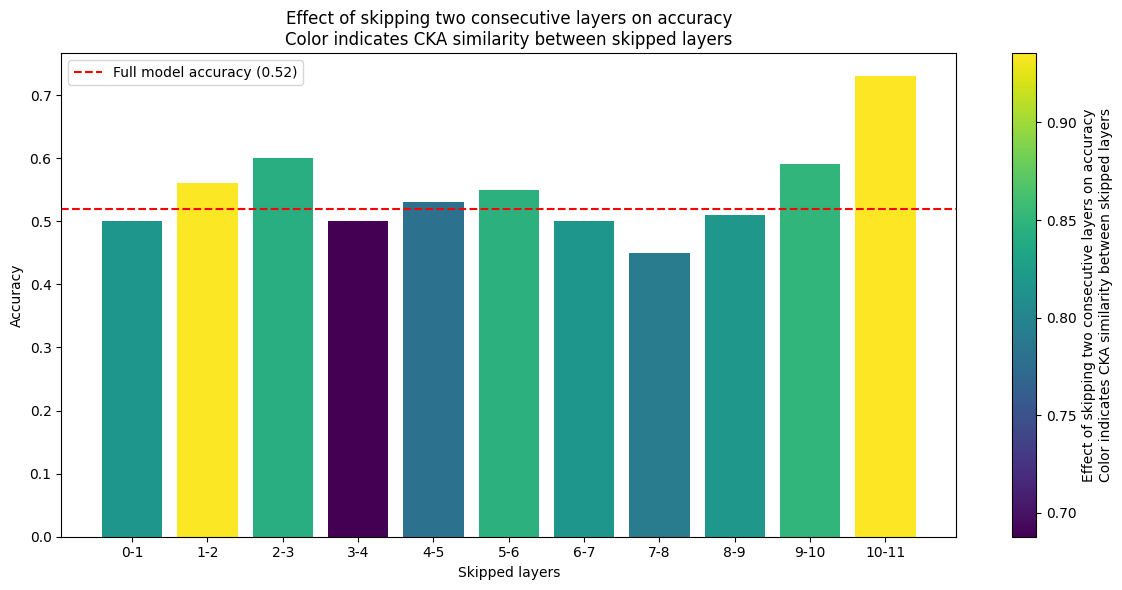

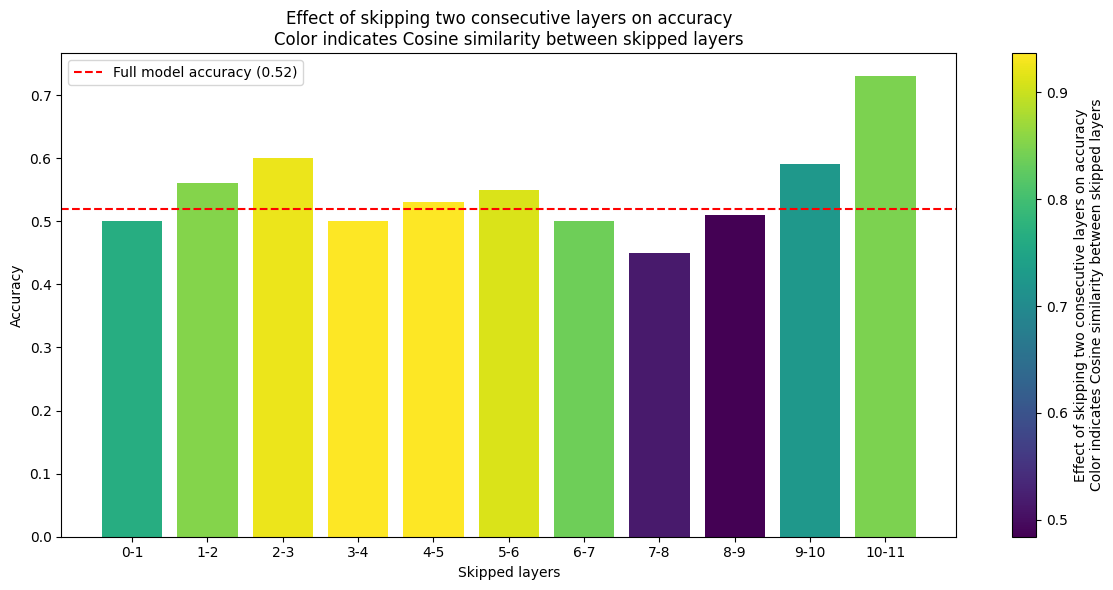

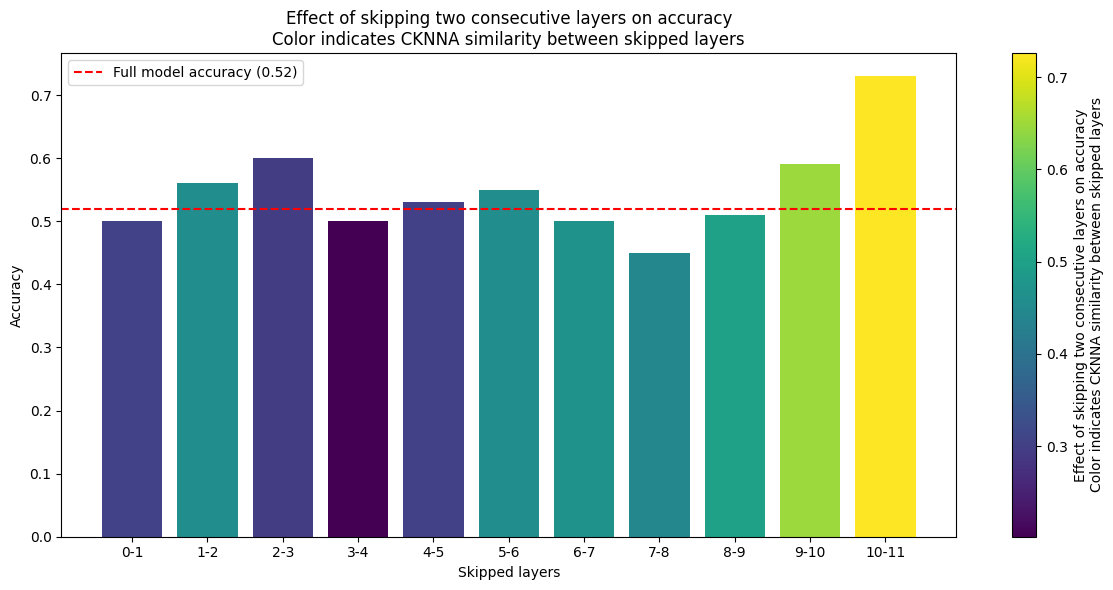

In [83]:
plot_double_skip_accuracy(
    results,
    cka_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates CKA similarity between skipped layers"
)

plot_double_skip_accuracy(
    results,
    cos_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates Cosine similarity between skipped layers"
)

plot_double_skip_accuracy(
    results,
    cknna_matrix,
    "Effect of skipping two consecutive layers on accuracy\nColor indicates CKNNA similarity between skipped layers"
)
